In [2]:
# Cell 1 — always run this first
import os
os.chdir('/home/darius/qgis_projects/land_change_detector')
print("Working directory:", os.getcwd())

Working directory: /home/darius/qgis_projects/land_change_detector


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
import sys

sys.path.insert(0, '/home/darius/qgis_projects/land_change_detector')
from utils.raster_utils import load_raster, get_raster_info

# ── Define your R10m path ──────────────────────────────────────────
R10m = (
    "/home/darius/qgis_projects/land_change_detector/data/before/"
    "S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/"
    "GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m"
)

# ── Check one band's info ──────────────────────────────────────────
get_raster_info(f"{R10m}/T31SGV_20190601T102029_B04_10m.jp2")

File     : T31SGV_20190601T102029_B04_10m.jp2
Size     : 10980 cols x 10980 rows
Bands    : 1
CRS      : PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_19...
Band 1   : min=0.0, max=16912.0, mean=3421.8


Image size: (10980, 10980)
Value range: 0 → 16912


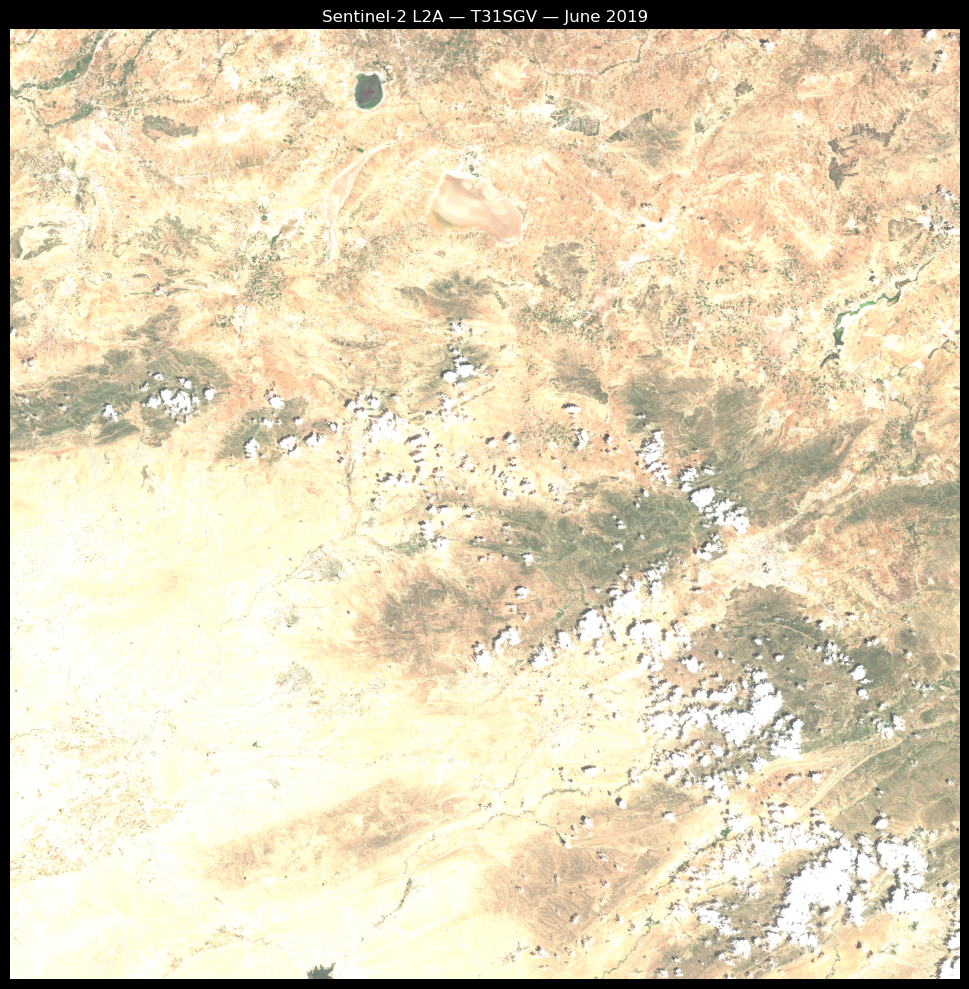

In [4]:
# Load Red, Green, Blue
red,   gt, proj = load_raster(f"{R10m}/T31SGV_20190601T102029_B04_10m.jp2")
green, _,  _    = load_raster(f"{R10m}/T31SGV_20190601T102029_B03_10m.jp2")
blue,  _,  _    = load_raster(f"{R10m}/T31SGV_20190601T102029_B02_10m.jp2")

# Each file loads as shape (1, rows, cols) → squeeze to (rows, cols)
red   = red.squeeze()
green = green.squeeze()
blue  = blue.squeeze()

print(f"Image size: {red.shape}")        # expect (10980, 10980)
print(f"Value range: {red.min():.0f} → {red.max():.0f}")

# Stack into RGB for display
rgb = np.stack([red, green, blue], axis=-1)

# Normalize: L2A values go up to ~10000 (surface reflectance x10000)
rgb_display = np.clip(rgb / 3000.0, 0, 1)

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(rgb_display)
plt.title("Sentinel-2 L2A — T31SGV — June 2019")
plt.axis('off')
plt.tight_layout()
plt.savefig("data/before/preview_before.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import sys
sys.path.insert(0, '/home/darius/qgis_projects/land_change_detector')
from algorithms.band_differencing import run_band_differencing

# Use Band 4 (Red) for testing
# We only have "before" data right now, so simulate "after" with noise
band_before = red   # from your loaded image
band_after  = red + np.random.normal(0, 300, red.shape)  # fake change

# Run the algorithm
results = run_band_differencing(band_before, band_after)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(band_before, cmap='gray')
axes[0].set_title("Before (Band 4)")
axes[0].axis('off')

axes[1].imshow(results['abs_diff'], cmap='hot')
axes[1].set_title(f"Absolute Difference\n(threshold={results['threshold']:.1f})")
axes[1].axis('off')

axes[2].imshow(results['change_mask'], cmap='RdYlGn_r')
axes[2].set_title(f"Change Mask\n({results['change_pct']:.1f}% changed)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("data/before/band_diff_test.png", dpi=150)
plt.show()

Auto threshold (Otsu): 244.02
Changed pixels : 52,894,729
Total pixels   : 120,560,400
Change %       : 43.87%
